# Brief 04 : Est-ce que ce prêt doit être accordé ou rejetté ?

In [1]:
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
from sklearn.experimental import enable_iterative_imputer  # Nécessaire pour activer l'IterativeImputer
from sklearn.impute import IterativeImputer

from sklearn.preprocessing import LabelEncoder


In [2]:
df = pd.read_csv("data/SBAnational.csv")
df.columns

/tmp/ipykernel_10453/992082409.py:1: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/SBAnational.csv")


Index(['LoanNr_ChkDgt', 'Name', 'City', 'State', 'Zip', 'Bank', 'BankState',
       'NAICS', 'ApprovalDate', 'ApprovalFY', 'Term', 'NoEmp', 'NewExist',
       'CreateJob', 'RetainedJob', 'FranchiseCode', 'UrbanRural', 'RevLineCr',
       'LowDoc', 'ChgOffDate', 'DisbursementDate', 'DisbursementGross',
       'BalanceGross', 'MIS_Status', 'ChgOffPrinGr', 'GrAppv', 'SBA_Appv'],
      dtype='object')

In [3]:
# Afficher le DataFrame nettoyé
df.shape[0]

899164

# Explication des colonnes

### Identification et localisation de l'entreprise

- **LoanNr_ChkDgt** : Numéro unique du prêt   <span style="color:red;">Useless</span>
- **Name** : Nom de l'entreprise bénéficiaire du prêt. <span style="color:red;">Useless</span>
- **City** : Ville où est située l'entreprise.  <span style="color:grey;">Redondant</span>
- **State** : État    <span style="color:green;">OK</span>
- **Zip** : Code postal   <span style="color:grey;">Redondant</span>

# Informations sur les prêts aux entreprises

## Informations sur la banque prêteuse

- **Bank** : Nom de la banque ayant accordé le prêt.  <span style="color:red;">Trop de valeurs uniques</span>
- **BankState** : État où est située la banque prêteuse.  <span style="color:green;">OK</span>

## Informations sur l'entreprise

- **NAICS** : Code de classification de l'industrie.   <span style="color:green;">OK</span>  -200.000 valeurs si not null notNaN
- **NoEmp** : Nombre d'employés de l'entreprise au moment de la demande de prêt.  <span style="color:green;">OK</span>
- **NewExist** : Indique si l'entreprise est nouvelle (**1**) ou existante (**2**). <span style="color:green;">OK</span> 

## Détails du prêt

- **ApprovalDate** : Date à laquelle le prêt a été approuvé.  <span style="color:grey;">redondant</span>
- **ApprovalFY** : Année fiscale d'approbation du prêt <span style="color:green;">OK</span>
- **Term** : Durée du prêt en mois.  <span style="color:green;">OK</span>
- **CreateJob** : Nombre d'emplois que l'entreprise prévoit de créer grâce au prêt.  <span style="color:green;">OK</span>
- **RetainedJob** : Nombre d'emplois que l'entreprise prévoit de conserver grâce au prêt.  <span style="color:green;">OK</span>
- **FranchiseCode** : Code indiquant si l'entreprise est une franchise (**00000** signifie que ce n'est pas une franchise).  <span style="color:green;">OK</span>
- **UrbanRural** : Indique si l'entreprise est située dans une zone **urbaine** (**1**), **rurale** (**2**), ou **non spécifiée** (**0**).  <span style="color:green;">OK</span>

## Conditions du prêt

- **RevLineCr** : Indique si le prêt est une ligne de crédit renouvelable <span style="color:green;">OK</span> 
- **LowDoc** : Indique si le prêt fait partie du programme *Low Documentation* <span style="color:green;">OK</span>

## Informations financières et remboursement

- **ChgOffDate** : Date à laquelle le prêt a été radié en cas de non-remboursement.  <span style="color:red;">Data Leaking</span>
- **DisbursementDate** : Date à laquelle les fonds ont été décaissés.  <span style="color:green;">OK</span>
- **DisbursementGross** : Montant total du prêt accordé.  <span style="color:green;">OK</span>
- **BalanceGross** : Montant restant dû sur le prêt.  <span style="color:red;">Data Leaking</span>
- **MIS_Status** : Statut du prêt :  <span style="color:blue;">TARGET</span>
  - **PIF (Paid In Full)** : Le prêt a été remboursé intégralement.  
  - **CHGOFF (Charged Off)** : Le prêt a été radié (perte pour la banque).  
- **ChgOffPrinGr** : Montant du principal du prêt qui a été radié (perdu par la banque).  <span style="color:red;">useless</span>
- **GrAppv** : Montant total approuvé par la banque.  <span style="color:green;">OK</span>
- **SBA_Appv** : Montant garanti par la *SBA* (une partie du prêt est garantie par l'agence).  <span style="color:green;">OK</span>


In [4]:
# df_issue = df[df['MIS_Status'].isna() | (df['LowDoc'] == 0)]
# df_issue.unique()

# df["RetainedJob"].unique()


In [5]:
# Nombre de zéros
num_zeros = (df["SBA_Appv"] == 0).sum()

# Nombre de valeurs NaN
num_nans = df["SBA_Appv"].isna().sum()

print(f"Nombre de zéros : {num_zeros}")
print(f"Nombre de NaN : {num_nans}")

df['SBA_Appv'].describe()


Nombre de zéros : 0
Nombre de NaN : 0


count          899164
unique          38326
top       $25,000.00 
freq            49579
Name: SBA_Appv, dtype: object

In [6]:
df["DisbursementDate"] = pd.to_datetime(df["DisbursementDate"], format="%d-%b-%y")
df["DisbursementDate"].describe() 

count                           896796
mean     2001-09-19 14:10:17.462165248
min                1969-05-22 00:00:00
25%                1997-05-31 00:00:00
50%                2002-12-31 00:00:00
75%                2006-03-31 00:00:00
max                2068-11-22 00:00:00
Name: DisbursementDate, dtype: object

compare 'DisbursementGross', 'GrAppv'

In [7]:
# On supprime les 14 lignes ou State = 0 ou null
# df_clean = df[
#     (df['State'] != 0) & (df['State'].notna()) &
#     (df['BankState'] != 0) & (df['BankState'].notna()) &
#     (df['NoEmp'] != 0) & (df['NoEmp'].notna()) &
#     (df['NewExist'] != 0) & (df['NewExist'].notna())&
#     (df['RetainedJob'].notna()) &
#     (df['CreateJob'].notna()) &
#     (df['UrbanRural'].notna()) &  #useless
#     (df['RevLineCr'].notna())&
#     (df['DisbursementDate'].notna())
# ]
df_clean = df
df_clean['NAICS_2'] = df_clean['NAICS'].astype(str).str[:2]
# df_clean = df_clean[df_clean['NAICS_2'].notna() & (df_clean['NAICS_2'] != '0')]
df_clean["FranchiseCode"] = df["FranchiseCode"].where(df["FranchiseCode"] == 0, 1)
df_clean["RevLineCr"] = df["RevLineCr"].map(lambda x: 0 if x in ["N", "0"] else (1 if x in ["Y", "1"] else np.nan))
df_clean["LowDoc"] = df["LowDoc"].map(lambda x: 0 if x == "N" else (1 if x == "Y" else np.nan))
df_clean["DisbursementDate"] = pd.to_datetime(df["DisbursementDate"], format="%d-%b-%y")

columns_to_keep = ['State','BankState','NAICS_2', 'NoEmp', 'NewExist', 'RetainedJob', 'CreateJob', 'UrbanRural', 'RevLineCr', 'ApprovalFY', 'DisbursementGross', 'GrAppv', 'SBA_Appv',  'LowDoc', 'MIS_Status']
# Vérifier le nombre de lignes après nettoyage
df_clean.shape[0]

899164

In [8]:
df2 = df_clean[columns_to_keep]
df2["MIS_Status"] = df2["MIS_Status"].map(lambda x: 1 if x == "P I F" else (0 if x== "CHGOFF" else np.nan) )
df2['DisbursementGross'] = df['DisbursementGross'].replace('[\$,]', '', regex=True).astype(float)
df2['GrAppv'] = df['GrAppv'].replace('[\$,]', '', regex=True).astype(float)
df2['SBA_Appv'] = df['SBA_Appv'].replace('[\$,]', '', regex=True).astype(float)
# df2['DisbursementDate'] = df2['DisbursementDate'].astype(str).str[:4]
# df2["DisbursementDate"] = df2["DisbursementDate"].astype(int)
df2['ApprovalFY'] = pd.to_numeric(df2['ApprovalFY'].astype(str).str[:4], errors='coerce').astype('Int64')
df2 = df2.dropna(subset=['MIS_Status'])

df2.head()

<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:4: SyntaxWarning: invalid escape sequence '\$'
<>:5: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:4: SyntaxWarning: invalid escape sequence '\$'
<>:5: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_10453/866963577.py:3: SyntaxWarning: invalid escape sequence '\$'
  df2['DisbursementGross'] = df['DisbursementGross'].replace('[\$,]', '', regex=True).astype(float)
/tmp/ipykernel_10453/866963577.py:4: SyntaxWarning: invalid escape sequence '\$'
  df2['GrAppv'] = df['GrAppv'].replace('[\$,]', '', regex=True).astype(float)
/tmp/ipykernel_10453/866963577.py:5: SyntaxWarning: invalid escape sequence '\$'
  df2['SBA_Appv'] = df['SBA_Appv'].replace('[\$,]', '', regex=True).astype(float)
/tmp/ipykernel_10453/866963577.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the cav

,State,BankState,NAICS_2,NoEmp,NewExist,RetainedJob,CreateJob,UrbanRural,RevLineCr,ApprovalFY,DisbursementGross,GrAppv,SBA_Appv,LowDoc,MIS_Status
0,IN,OH,45,4,2.0,0,0,0,0.0,1997,60000.0,60000.0,48000.0,1.0,1.0
1,IN,IN,72,2,2.0,0,0,0,0.0,1997,40000.0,40000.0,32000.0,1.0,1.0
2,IN,IN,62,7,1.0,0,0,0,0.0,1997,287000.0,287000.0,215250.0,0.0,1.0
3,OK,OK,0,2,1.0,0,0,0,0.0,1997,35000.0,35000.0,28000.0,1.0,1.0
4,FL,FL,0,14,1.0,7,7,0,0.0,1997,229000.0,229000.0,229000.0,0.0,1.0


In [9]:
label_encoder = LabelEncoder()
df2['State'] = label_encoder.fit_transform(df2['State'])
df2['BankState'] = label_encoder.fit_transform(df2['BankState'])

In [10]:
df2.head()

,State,BankState,NAICS_2,NoEmp,NewExist,RetainedJob,CreateJob,UrbanRural,RevLineCr,ApprovalFY,DisbursementGross,GrAppv,SBA_Appv,LowDoc,MIS_Status
0,15,38,45,4,2.0,0,0,0,0.0,1997,60000.0,60000.0,48000.0,1.0,1.0
1,15,18,72,2,2.0,0,0,0,0.0,1997,40000.0,40000.0,32000.0,1.0,1.0
2,15,18,62,7,1.0,0,0,0,0.0,1997,287000.0,287000.0,215250.0,0.0,1.0
3,36,39,0,2,1.0,0,0,0,0.0,1997,35000.0,35000.0,28000.0,1.0,1.0
4,9,11,0,14,1.0,7,7,0,0.0,1997,229000.0,229000.0,229000.0,0.0,1.0


In [11]:
df2.describe()

,State,BankState,NoEmp,NewExist,RetainedJob,CreateJob,UrbanRural,RevLineCr,ApprovalFY,DisbursementGross,GrAppv,SBA_Appv,LowDoc,MIS_Status
count,897167.000000,897167.000000,897167.000000,897033.000000,897167.000000,897167.000000,897167.000000,877366.000000,897167.0,8.971670e+05,8.971670e+05,8.971670e+05,891168.000000,897167.000000
mean,23.758333,28.145342,11.412562,1.280403,10.807308,8.444305,0.757274,0.228734,2001.139677,2.015980e+05,1.930595e+05,1.497807e+05,0.123625,0.824383
std,15.125035,15.808775,73.793775,0.451741,237.382398,236.950249,0.646540,0.420017,5.912461,2.878066e+05,2.834331e+05,2.285600e+05,0.329154,0.380494
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1966.0,4.000000e+03,1.000000e+03,5.000000e+02,0.000000,0.000000
25%,9.000000,15.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1997.0,4.249200e+04,3.500000e+04,2.125000e+04,0.000000,1.000000
50%,23.000000,30.000000,4.000000,1.000000,1.000000,0.000000,1.000000,0.000000,2002.0,1.000000e+05,9.000000e+04,6.205000e+04,0.000000,1.000000
75%,37.000000,43.000000,10.000000,2.000000,4.000000,1.000000,1.000000,0.000000,2006.0,2.390000e+05,2.250000e+05,1.750000e+05,0.000000,1.000000
max,51.000000,56.000000,9999.000000,2.000000,9500.000000,8800.000000,2.000000,1.000000,2014.0,1.144632e+07,5.472000e+06,5.472000e+06,1.000000,1.000000


In [12]:
nan_count = df2['MIS_Status'].isna().sum()
unique_values = df2['MIS_Status'].unique()

print(f"Nombre de lignes avec NaN dans MIS_Status : {nan_count}")
print(f"Valeurs uniques dans MIS_Status : {unique_values}")

Nombre de lignes avec NaN dans MIS_Status : 0
Valeurs uniques dans MIS_Status : [1. 0.]


In [13]:
df2.isna().sum()

State                    0
BankState                0
NAICS_2                  0
NoEmp                    0
NewExist               134
RetainedJob              0
CreateJob                0
UrbanRural               0
RevLineCr            19801
ApprovalFY               0
DisbursementGross        0
GrAppv                   0
SBA_Appv                 0
LowDoc                5999
MIS_Status               0
dtype: int64

#
stratify target [target, date]


<Axes: >

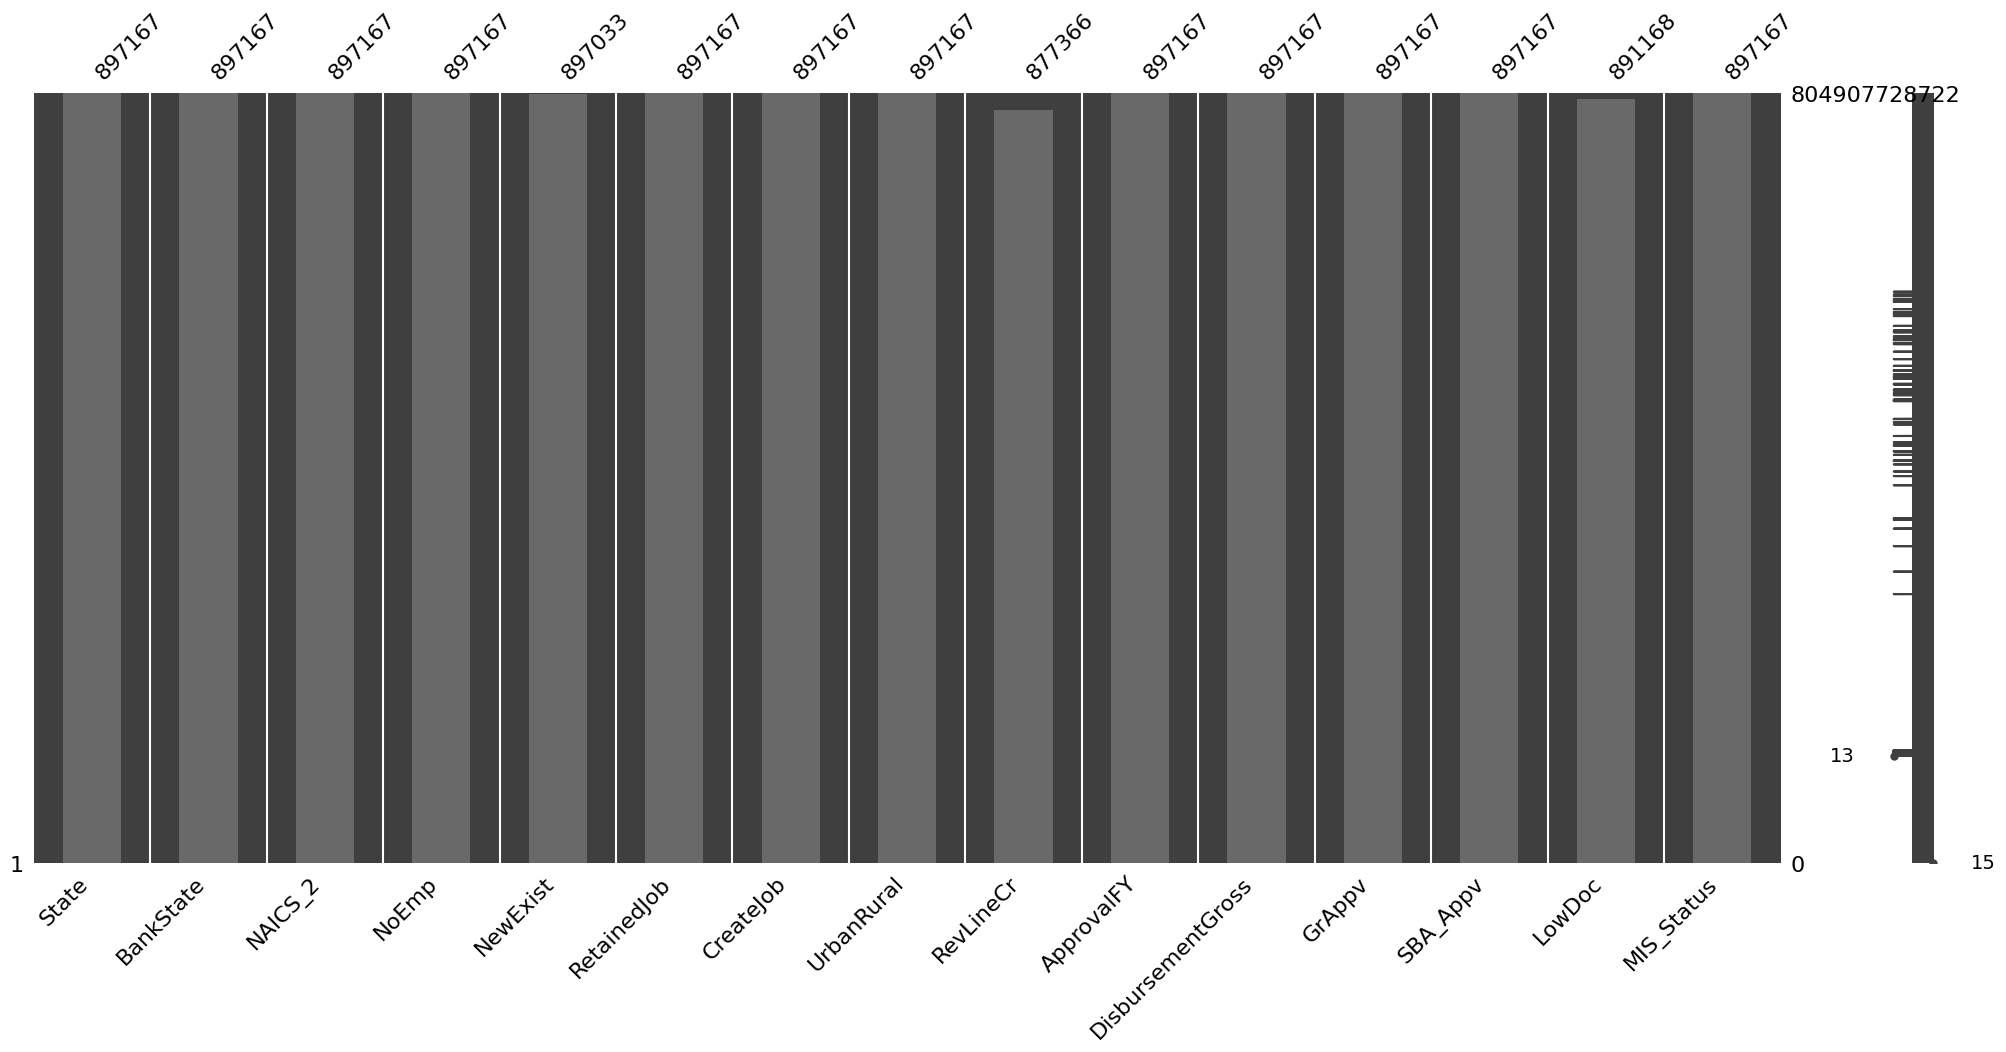

In [14]:
msno.matrix(df2)
msno.bar(df2)

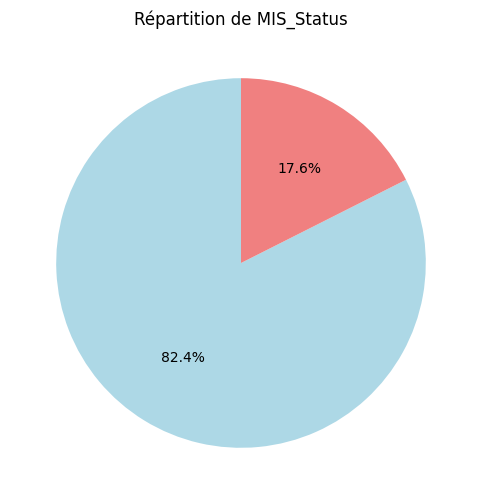

In [15]:
# Création du camembert
plt.figure(figsize=(6, 6))
plt.pie(df['MIS_Status'].value_counts(), autopct='%1.1f%%', startangle=90, colors=['lightblue', 'lightcoral'])

# Ajouter un titre
plt.title("Répartition de MIS_Status")

# Afficher le graphique
plt.show()

In [16]:
# Initialisation de l'IterativeImputer
imputer = IterativeImputer(max_iter=10, random_state=42)

# Appliquer l'imputation
df_imputed = pd.DataFrame(imputer.fit_transform(df2), columns=df2.columns)

# Afficher le DataFrame après imputation
print(df_imputed)

        State  BankState  NAICS_2  NoEmp  NewExist  RetainedJob  CreateJob  \
0        15.0       38.0     45.0    4.0       2.0          0.0        0.0   
1        15.0       18.0     72.0    2.0       2.0          0.0        0.0   
2        15.0       18.0     62.0    7.0       1.0          0.0        0.0   
3        36.0       39.0      0.0    2.0       1.0          0.0        0.0   
4         9.0       11.0      0.0   14.0       1.0          7.0        7.0   
...       ...        ...      ...    ...       ...          ...        ...   
897162   35.0       17.0     45.0    6.0       1.0          0.0        0.0   
897163   35.0       17.0     45.0    6.0       1.0          0.0        0.0   
897164    4.0        5.0     33.0   26.0       1.0          0.0        0.0   
897165   11.0       14.0      0.0    6.0       1.0          0.0        0.0   
897166   11.0       14.0      0.0    1.0       2.0          0.0        0.0   

        UrbanRural  RevLineCr  ApprovalFY  DisbursementGross   

In [17]:
df_imputed.isna().sum()

State                0
BankState            0
NAICS_2              0
NoEmp                0
NewExist             0
RetainedJob          0
CreateJob            0
UrbanRural           0
RevLineCr            0
ApprovalFY           0
DisbursementGross    0
GrAppv               0
SBA_Appv             0
LowDoc               0
MIS_Status           0
dtype: int64

In [18]:
df2.shape[0]


897167

In [19]:
df.shape[0]

899164

In [20]:
df_zip_zero = df[df['Zip'] == 0]
df_zip_zero.shape[0]   # 283 lines

df_zip_zero = df[df['Zip'] == 0][['State', 'City']]

# Afficher les premières lignes des résultats
df_zip_zero.head()

,State,City
64,OR,Grass Valley
119,MO,Wappapello
7299,WA,WASHOUGAL
7693,CA,CORTE MADERA
13073,WV,FAYETTEVILLE


In [21]:
df_nulls = df[df["Zip"].isnull()]
print(df_nulls[["State", "Zip"]])

Empty DataFrame
Columns: [State, Zip]
Index: []


## Duplicates CHECK : OK

In [22]:
df[['ApprovalFY', 'ApprovalDate']]

,ApprovalFY,ApprovalDate
0,1997,28-Feb-97
1,1997,28-Feb-97
2,1997,28-Feb-97
3,1997,28-Feb-97
4,1997,28-Feb-97
...,...,...
899159,1997,27-Feb-97
899160,1997,27-Feb-97
899161,1997,27-Feb-97
899162,1997,27-Feb-97


In [23]:
df.duplicated().sum()

np.int64(0)

In [24]:
df[ "ChgOffPrinGr"][(df["MIS_Status"] == "P I F") & (df['ChgOffPrinGr'] != "$0.00 ")]

558        $3,330.00 
850       $10,270.00 
853       $97,486.00 
861        $2,310.00 
866        $3,783.00 
             ...     
895467     $6,462.00 
895669    $46,165.00 
897114    $20,878.00 
897735    $17,236.00 
898966    $30,002.00 
Name: ChgOffPrinGr, Length: 4884, dtype: object

# 1. PRE-PROCESSING

## 1.1. FEATURE SELECTION

In [25]:
# On filtre la db pour ne garder que les colonnes nécessaire à la régression logistique

# columns_to_keep = [
#     "NAICS", "City", "State", "Zip", "Bank", "BankState", "MIS_Status",
#     "NoEmp", "NewExist", "CreateJob", "RetainedJob",
#     "FranchiseCode", "UrbanRural", "RevLineCr"
# ]

filtered_df = df[columns_to_keep]
filtered_df.head(10)



,State,BankState,NAICS_2,NoEmp,NewExist,RetainedJob,CreateJob,UrbanRural,RevLineCr,ApprovalFY,DisbursementGross,GrAppv,SBA_Appv,LowDoc,MIS_Status
0,IN,OH,45,4,2.0,0,0,0,0.0,1997,"$60,000.00","$60,000.00","$48,000.00",1.0,P I F
1,IN,IN,72,2,2.0,0,0,0,0.0,1997,"$40,000.00","$40,000.00","$32,000.00",1.0,P I F
2,IN,IN,62,7,1.0,0,0,0,0.0,1997,"$287,000.00","$287,000.00","$215,250.00",0.0,P I F
3,OK,OK,0,2,1.0,0,0,0,0.0,1997,"$35,000.00","$35,000.00","$28,000.00",1.0,P I F
4,FL,FL,0,14,1.0,7,7,0,0.0,1997,"$229,000.00","$229,000.00","$229,000.00",0.0,P I F
5,CT,DE,33,19,1.0,0,0,0,0.0,1997,"$517,000.00","$517,000.00","$387,750.00",0.0,P I F
6,NJ,SD,0,45,2.0,0,0,0,0.0,1980,"$600,000.00","$600,000.00","$499,998.00",0.0,CHGOFF
7,FL,AL,81,1,2.0,0,0,0,0.0,1997,"$45,000.00","$45,000.00","$36,000.00",1.0,P I F
8,FL,FL,72,2,2.0,0,0,0,0.0,1997,"$305,000.00","$305,000.00","$228,750.00",0.0,P I F
9,CT,CT,0,3,2.0,0,0,0,0.0,1997,"$70,000.00","$70,000.00","$56,000.00",1.0,P I F


## 1.2. Formatage des données

In [26]:
# Supprimer le signe dollar ($) et les virgules dans la colonne "GrAppv"
# filtered_df['GrAppv'] = filtered_df['GrAppv'].replace({'\$': '', '': ''}, regex=True).astype(float)
# # filtered_df.head(3)
# print(f"type is :{type(filtered_df["GrAppv"])}")

## 1.3. Vérification des valeurs nulles

In [27]:
filtered_df.isnull().sum()  # Vérifier les valeurs manquantes


State                   14
BankState             1566
NAICS_2                  0
NoEmp                    0
NewExist               136
RetainedJob              0
CreateJob                0
UrbanRural               0
RevLineCr            19854
ApprovalFY               0
DisbursementGross        0
GrAppv                   0
SBA_Appv                 0
LowDoc                6007
MIS_Status            1997
dtype: int64

## 1.4. INPUTING


In [28]:
print(type(45.000))


<class 'float'>
